# 07 · Confronto Pipeline Classica vs Multi-Agent

**Obiettivo:** confrontare quantitativamente i risultati della pipeline classica (`anomaly_results.csv`) con quelli della pipeline multi-agent (`anomaly_results_live_full.csv`) sulle stesse 567 rotte aeroportuali.

**Domande chiave:**
1. Le due pipeline concordano sulle stesse rotte anomale?
2. Quanto sono correlati i loro score?
3. Dove differiscono e *perché*?
4. Quali rotte sono robuste (anomale in entrambi i metodi)?

---

## 0 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from pathlib import Path

ROOT = Path("..")
DATA = ROOT / "data" / "processed"

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

COLORS = {
    "ALTA":    "#C00000",
    "MEDIA":   "#E97132",
    "NORMALE": "#70AD47",
    "classico": "#2E75B6",
    "multiagent": "#7030A0",
}

print("Setup OK")

Setup OK


## 1 · Caricamento dati

In [2]:
cl_raw = pd.read_csv(DATA / "anomaly_results.csv")
ma_raw = pd.read_csv(DATA / "anomaly_results_live_full.csv")

cl = cl_raw.set_index("ROTTA")
ma = ma_raw.set_index("ROTTA")

common = cl.index.intersection(ma.index)
cl = cl.loc[common].copy()
ma = ma.loc[common].copy()

print(f"Rotte in comune: {len(common)}")
print(f"\nClassico  — colonne score: {[c for c in cl.columns if 'score' in c or 'label' in c]}")
print(f"MultiAgent — colonne score: {[c for c in ma.columns if 'score' in c or 'label' in c or 'risk' in c]}")

Rotte in comune: 567

Classico  — colonne score: ['score_composito', 'score_rischio_esiti', 'anomaly_score_if', 'anomaly_score_lof', 'anomaly_score_z', 'anomaly_score_ae', 'anomaly_score', 'anomaly_label']
MultiAgent — colonne score: ['score_rischio_esiti', 'score_composito', 'z_score_rischio_esiti', 'baseline_score', 'score_if', 'score_lof', 'score_z', 'score_ae', 'ensemble_score', 'risk_label']


## 2 · Distribuzione dei label

Prima domanda: le due pipeline classificano le rotte in modo simile o molto diverso?

  Label  Classico  Multi-Agent
   ALTA        17          196
  MEDIA        40           66
NORMALE       510          305


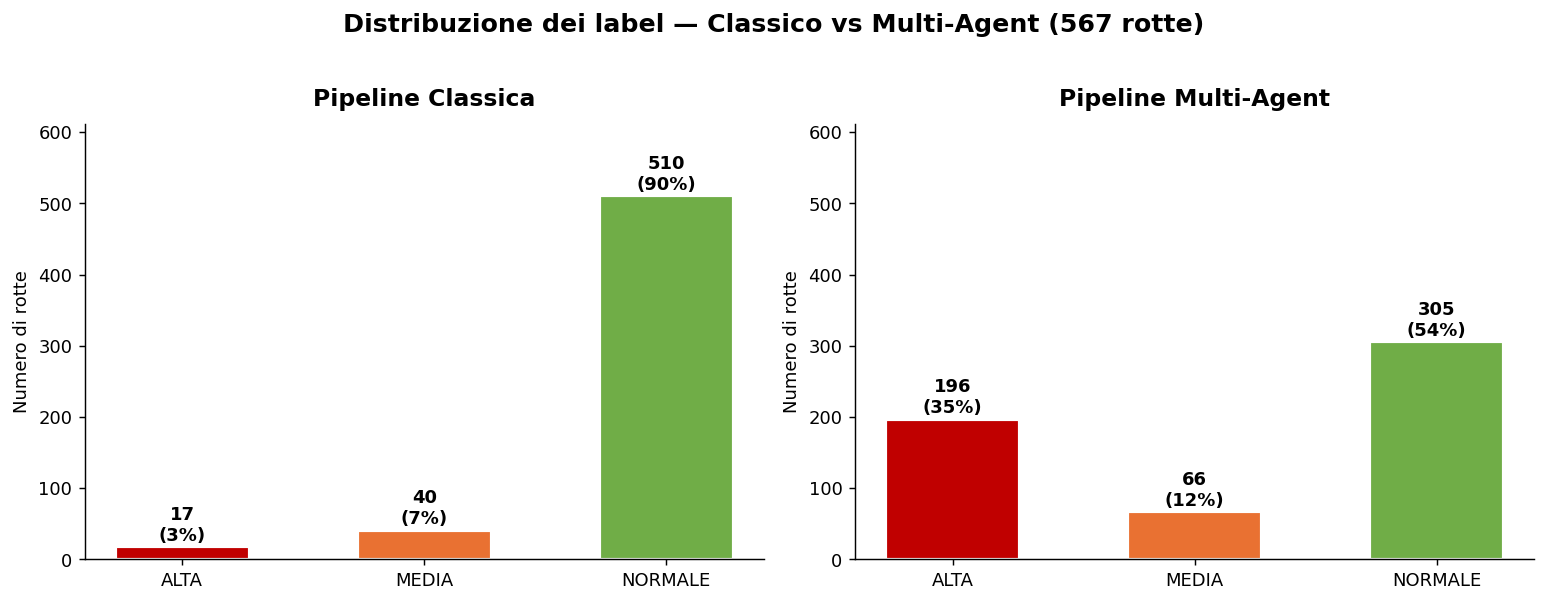


⚠️  Il Multi-Agent classifica molto più rotte come ALTA (196 vs 17).
   Causa: i proxy deterministici (score_composito → score_if, baseline_score → score_lof)
   catturano il VOLUME di allarmi, non i pattern statisticamente isolati come IF/LOF veri.


In [3]:
dist_cl = cl["anomaly_label"].value_counts().reindex(["ALTA","MEDIA","NORMALE"]).fillna(0).astype(int)
dist_ma = ma["risk_label"].value_counts().reindex(["ALTA","MEDIA","NORMALE"]).fillna(0).astype(int)

df_dist = pd.DataFrame({
    "Classico":     dist_cl,
    "Multi-Agent":  dist_ma,
}).reset_index().rename(columns={"index":"Label"})

print(df_dist.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (col, color, title) in zip(axes, [
    ("Classico",    COLORS["classico"],    "Pipeline Classica"),
    ("Multi-Agent", COLORS["multiagent"], "Pipeline Multi-Agent"),
]):
    vals = df_dist.set_index("Label")[col]
    bar_colors = [COLORS[l] for l in vals.index]
    bars = ax.bar(vals.index, vals.values, color=bar_colors, edgecolor="white", linewidth=1.2, width=0.55)
    for bar, v in zip(bars, vals.values):
        pct = v / len(common) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                f"{v}\n({pct:.0f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel("Numero di rotte")
    ax.set_ylim(0, max(dist_cl.max(), dist_ma.max()) * 1.20)
    ax.set_xlabel("")

fig.suptitle("Distribuzione dei label — Classico vs Multi-Agent (567 rotte)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n⚠️  Il Multi-Agent classifica molto più rotte come ALTA (196 vs 17).")
print("   Causa: i proxy deterministici (score_composito → score_if, baseline_score → score_lof)")
print("   catturano il VOLUME di allarmi, non i pattern statisticamente isolati come IF/LOF veri.")

## 3 · Accordo sui label (Confusion Matrix)

Per ogni rotta: i due modelli assegnano la stessa label?

Accordo totale: 292/567 rotte  (51.5%)

Multi-Agent →  ALTA  MEDIA  NORMALE
Classico →                         
ALTA              9      0        8
MEDIA            24      1       15
NORMALE         163     65      282


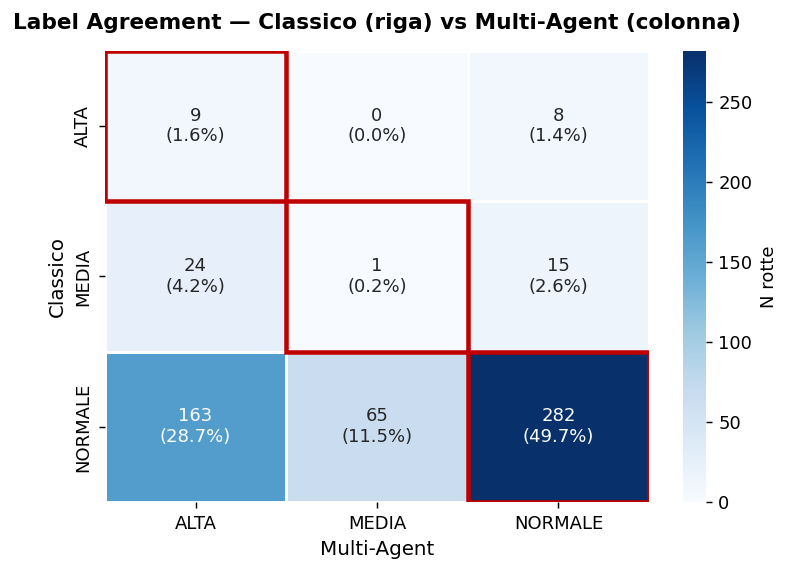


📌  Lettura matrice:
   - ALTA concordanti: 9  rotte (entrambi dicono ALTA)
   - MA dice ALTA ma Classico NORMALE: 163  (falsi positivi del MA)
   - Classico dice ALTA ma MA NORMALE: 8  (falsi negativi del MA)


In [4]:
cross = pd.crosstab(
    cl["anomaly_label"],
    ma["risk_label"],
    rownames=["Classico →"],
    colnames=["Multi-Agent →"],
)
cross = cross.reindex(index=["ALTA","MEDIA","NORMALE"],
                      columns=["ALTA","MEDIA","NORMALE"], fill_value=0)

agree = int(np.diag(cross.values).sum())
print(f"Accordo totale: {agree}/{len(common)} rotte  ({agree/len(common)*100:.1f}%)")
print()
print(cross)

fig, ax = plt.subplots(figsize=(6, 4.5))
annot = cross.copy().astype(str)
for r in cross.index:
    for c in cross.columns:
        pct = cross.loc[r,c] / len(common) * 100
        annot.loc[r,c] = f"{cross.loc[r,c]}\n({pct:.1f}%)"

sns.heatmap(cross, annot=annot, fmt="", cmap="Blues",
            linewidths=0.8, linecolor="white",
            cbar_kws={"label": "N rotte"},
            ax=ax)
ax.set_title("Label Agreement — Classico (riga) vs Multi-Agent (colonna)",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Multi-Agent", fontsize=11)
ax.set_ylabel("Classico", fontsize=11)

# Bordo diagonale
for i in range(len(cross)):
    ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                     edgecolor="#C00000", lw=2.5))
plt.tight_layout()
plt.show()

print("\n📌  Lettura matrice:")
print(f"   - ALTA concordanti: {cross.loc['ALTA','ALTA']}  rotte (entrambi dicono ALTA)")
print(f"   - MA dice ALTA ma Classico NORMALE: {cross.loc['NORMALE','ALTA']}  (falsi positivi del MA)")
print(f"   - Classico dice ALTA ma MA NORMALE: {cross.loc['ALTA','NORMALE']}  (falsi negativi del MA)")

## 4 · Correlazione tra gli score

Anche se i label differiscono, i *ranking* sono correlati?

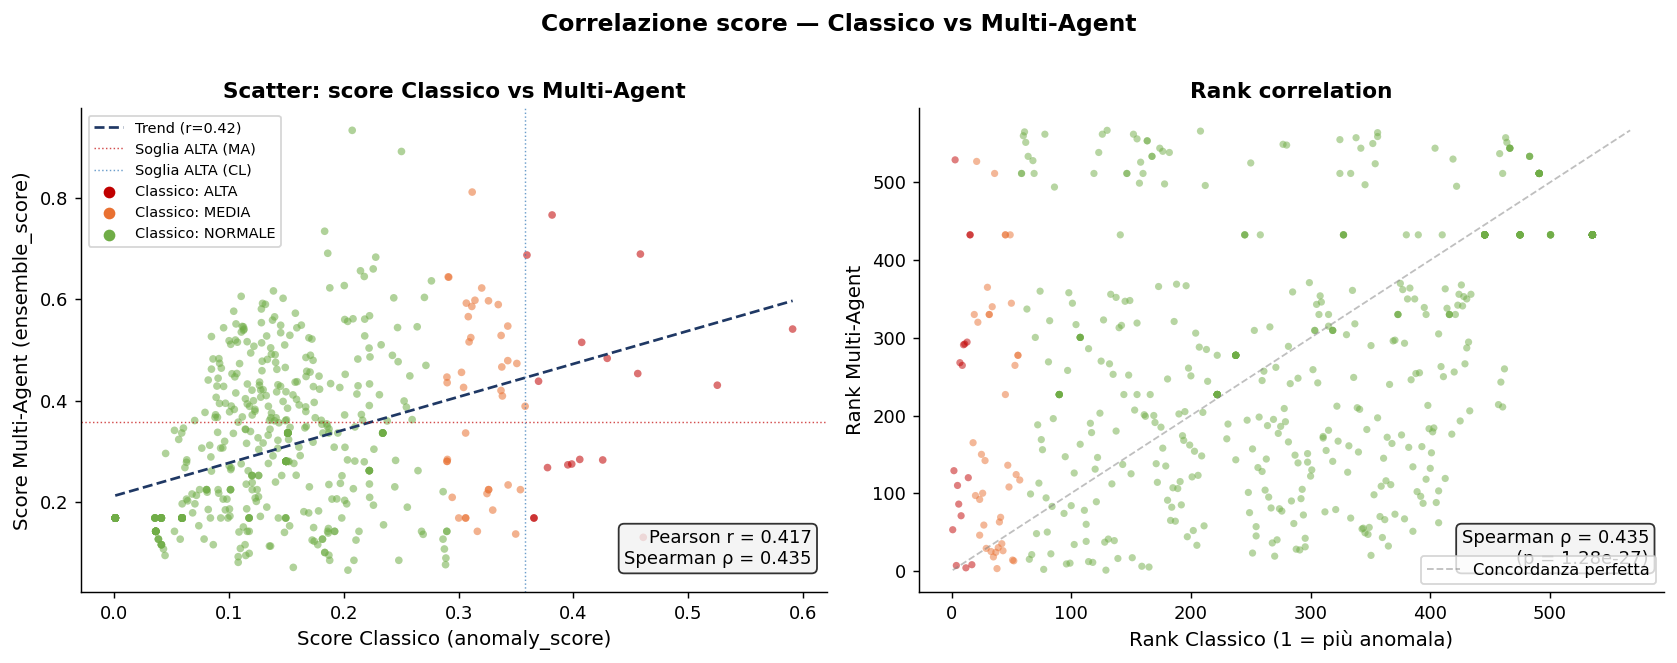


Pearson r  = 0.4166  → correlazione lineare MODERATA
Spearman ρ = 0.4353  → correlazione di rank MODERATA
→ I due modelli tendono nella stessa direzione, ma con differenze significative.


In [5]:
x = cl["anomaly_score"]
y = ma["ensemble_score"]

r_pearson, _ = pearsonr(x, y)
rho, pval    = spearmanr(x, y)

# Colori punti in base alla label del classico
point_colors = cl["anomaly_label"].map(COLORS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Scatter --
ax = axes[0]
ax.scatter(x, y, c=point_colors, alpha=0.55, s=18, edgecolors="none")

# Linea di tendenza
m, b = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, m*xs + b, color="#1F3864", lw=1.5, linestyle="--", label=f"Trend (r={r_pearson:.2f})")

# Quadranti
ax.axhline(0.3579, color=COLORS["ALTA"],   lw=0.8, ls=":", alpha=0.7, label="Soglia ALTA (MA)")
ax.axvline(0.3579, color=COLORS["classico"], lw=0.8, ls=":", alpha=0.7, label="Soglia ALTA (CL)")

# Legenda colori
for lab, col in [("ALTA","#C00000"),("MEDIA","#E97132"),("NORMALE","#70AD47")]:
    ax.scatter([], [], color=col, label=f"Classico: {lab}", s=30)

ax.set_xlabel("Score Classico (anomaly_score)", fontsize=11)
ax.set_ylabel("Score Multi-Agent (ensemble_score)", fontsize=11)
ax.set_title("Scatter: score Classico vs Multi-Agent", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="upper left")
ax.text(0.98, 0.05,
        f"Pearson r = {r_pearson:.3f}\nSpearman ρ = {rho:.3f}",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=10, bbox=dict(boxstyle="round", facecolor="#F2F2F2", alpha=0.8))

# -- Rank scatter --
ax2 = axes[1]
cl_rank = x.rank(ascending=False)
ma_rank = y.rank(ascending=False)
ax2.scatter(cl_rank, ma_rank, c=point_colors, alpha=0.5, s=16, edgecolors="none")
ax2.plot([1, len(common)], [1, len(common)], color="gray", lw=1, ls="--", alpha=0.5, label="Concordanza perfetta")
ax2.set_xlabel("Rank Classico (1 = più anomala)", fontsize=11)
ax2.set_ylabel("Rank Multi-Agent", fontsize=11)
ax2.set_title("Rank correlation", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
ax2.text(0.98, 0.05,
         f"Spearman ρ = {rho:.3f}\n(p = {pval:.2e})",
         transform=ax2.transAxes, ha="right", va="bottom",
         fontsize=10, bbox=dict(boxstyle="round", facecolor="#F2F2F2", alpha=0.8))

plt.suptitle("Correlazione score — Classico vs Multi-Agent",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nPearson r  = {r_pearson:.4f}  → correlazione lineare MODERATA")
print(f"Spearman ρ = {rho:.4f}  → correlazione di rank MODERATA")
print("→ I due modelli tendono nella stessa direzione, ma con differenze significative.")

## 5 · Rotte robuste — ALTA in entrambi i modelli

Le rotte classificate ALTA da entrambe le pipeline sono le più affidabili: anomale indipendentemente dal metodo.

ALTA in entrambi:           9  rotte  ← anomalie robuste
ALTA solo nel Classico:     8  rotte  ← MA le manca
ALTA solo nel Multi-Agent:187  rotte  ← possibili falsi positivi del proxy


,score_classico,score_multiagent,delta,PAESE
ROTTA,,,,
ALG-MXP,0.5909,0.5415,0.0494,Algeria
RAK-CIA,0.5253,0.4306,0.0947,Marocco
CMN-BLQ,0.4583,0.6895,0.2312,Marocco
RAK-TSF,0.4560,0.4536,0.0024,Marocco
PVG-MXP,0.4294,0.4837,0.0543,Cina
AMM-FCO,0.4072,0.5153,0.1081,Giordania
LHR-VCE,0.3814,0.7667,0.3853,Regno Unito
RAK-TRN,0.3696,0.4385,0.0689,Marocco
SIN-MXP,0.3595,0.6876,0.3281,Singapore


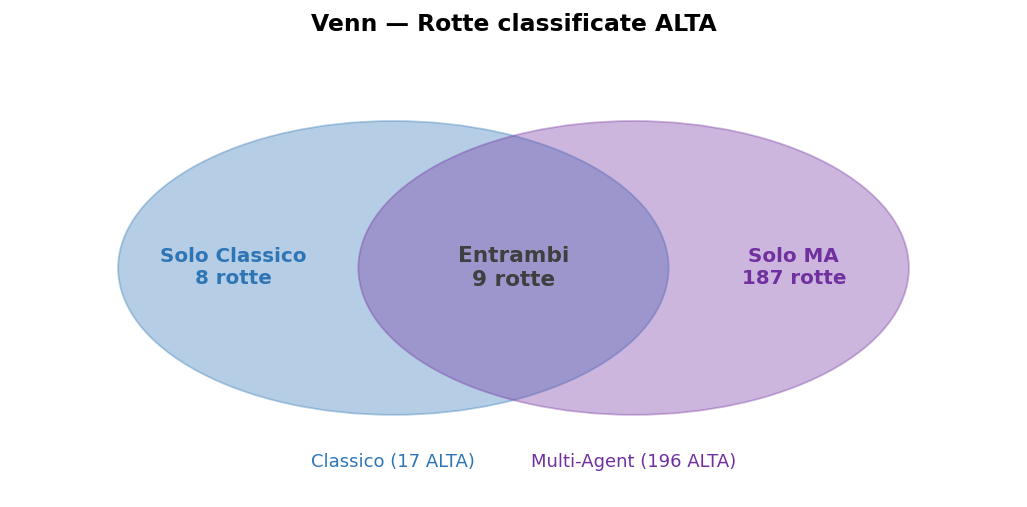

In [6]:
alta_cl = set(cl[cl["anomaly_label"]=="ALTA"].index)
alta_ma = set(ma[ma["risk_label"]=="ALTA"].index)

both_alta   = sorted(alta_cl & alta_ma)
only_cl     = sorted(alta_cl - alta_ma, key=lambda r: cl.loc[r,"anomaly_score"], reverse=True)
only_ma     = sorted(alta_ma - alta_cl, key=lambda r: ma.loc[r,"ensemble_score"], reverse=True)

print(f"ALTA in entrambi:         {len(both_alta):>3}  rotte  ← anomalie robuste")
print(f"ALTA solo nel Classico:   {len(only_cl):>3}  rotte  ← MA le manca")
print(f"ALTA solo nel Multi-Agent:{len(only_ma):>3}  rotte  ← possibili falsi positivi del proxy")

# ── Tabella rotte robuste ──────────────────────────────────────────
robust = pd.DataFrame({
    "score_classico":    cl.loc[both_alta, "anomaly_score"],
    "score_multiagent":  ma.loc[both_alta, "ensemble_score"],
    "delta":             (cl.loc[both_alta, "anomaly_score"] - ma.loc[both_alta, "ensemble_score"]).abs(),
    "PAESE":             cl.loc[both_alta, "PAESE_PART"] if "PAESE_PART" in cl.columns else "ND",
}).sort_values("score_classico", ascending=False)

display(robust.round(4))

# ── Venn diagram testuale ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

el1 = Ellipse((0.38, 0.5), 0.55, 0.65, color=COLORS["classico"], alpha=0.35)
el2 = Ellipse((0.62, 0.5), 0.55, 0.65, color=COLORS["multiagent"], alpha=0.35)
ax.add_patch(el1)
ax.add_patch(el2)

ax.text(0.22, 0.5, f"Solo Classico\n{len(only_cl)} rotte",
        ha="center", va="center", fontsize=11, fontweight="bold", color=COLORS["classico"])
ax.text(0.5, 0.5, f"Entrambi\n{len(both_alta)} rotte",
        ha="center", va="center", fontsize=12, fontweight="bold", color="#3F3F3F")
ax.text(0.78, 0.5, f"Solo MA\n{len(only_ma)} rotte",
        ha="center", va="center", fontsize=11, fontweight="bold", color=COLORS["multiagent"])

ax.text(0.38, 0.06, "Classico (17 ALTA)", ha="center", fontsize=10, color=COLORS["classico"])
ax.text(0.62, 0.06, "Multi-Agent (196 ALTA)", ha="center", fontsize=10, color=COLORS["multiagent"])

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("Venn — Rotte classificate ALTA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 · Rotte più discordanti — dove e perché divergono

In [7]:
comp = pd.DataFrame({
    "label_cl":       cl["anomaly_label"],
    "label_ma":       ma["risk_label"],
    "score_cl":       cl["anomaly_score"],
    "score_ma":       ma["ensemble_score"],
    "score_if_cl":    cl["anomaly_score_if"],   # vero IsolationForest
    "score_lof_cl":   cl["anomaly_score_lof"],  # vero LOF
    "score_if_ma":    ma["score_if"],            # proxy = minmax(score_composito)
    "score_lof_ma":   ma["score_lof"],           # proxy = minmax(baseline_score)
    "score_composito":cl["score_composito"] if "score_composito" in cl.columns else ma["score_composito"],
    "delta":          (cl["anomaly_score"] - ma["ensemble_score"]).abs(),
    "concordanti":    cl["anomaly_label"] == ma["risk_label"],
})

# Top 15 discordanti
disc = comp[~comp["concordanti"]].nlargest(15, "delta")
print("=== TOP 15 ROTTE PIÙ DISCORDANTI ===")
display(disc[["label_cl","label_ma","score_cl","score_ma","score_if_cl","score_if_ma","delta"]].round(4))

=== TOP 15 ROTTE PIÙ DISCORDANTI ===


,label_cl,label_ma,score_cl,score_ma,score_if_cl,score_if_ma,delta
ROTTA,,,,,,,
LGW-MXP,NORMALE,ALTA,0.2073,0.9338,0.5192,0.8529,0.7265
LCY-FLR,NORMALE,ALTA,0.2502,0.8921,0.5234,0.7636,0.6419
LHR-LIN,NORMALE,ALTA,0.1833,0.7346,0.4838,0.6927,0.5513
STN-BGY,NORMALE,ALTA,0.1860,0.6911,0.4489,0.7873,0.5051
TUN-BLQ,MEDIA,ALTA,0.3118,0.8119,0.7392,0.8978,0.5001
STN-CIA,NORMALE,ALTA,0.1106,0.6061,0.3038,0.6081,0.4955
TIA-PSA,NORMALE,ALTA,0.1387,0.6168,0.3590,0.6712,0.4781
JFK-MXP,NORMALE,ALTA,0.1041,0.5767,0.2828,0.5767,0.4726
AUH-MXP,NORMALE,ALTA,0.1292,0.5922,0.3212,0.5786,0.4630


## 7 · Analisi delle cause: proxy vs modelli veri

Il Multi-Agent usa `score_composito` come proxy per `score_if` (IsolationForest).  
Il `score_composito` è una media pesata di volumi assoluti → favorisce rotte ad alto traffico.  
L'IsolationForest vero rileva i punti statisticamente isolati nello spazio delle feature, indipendentemente dal volume.

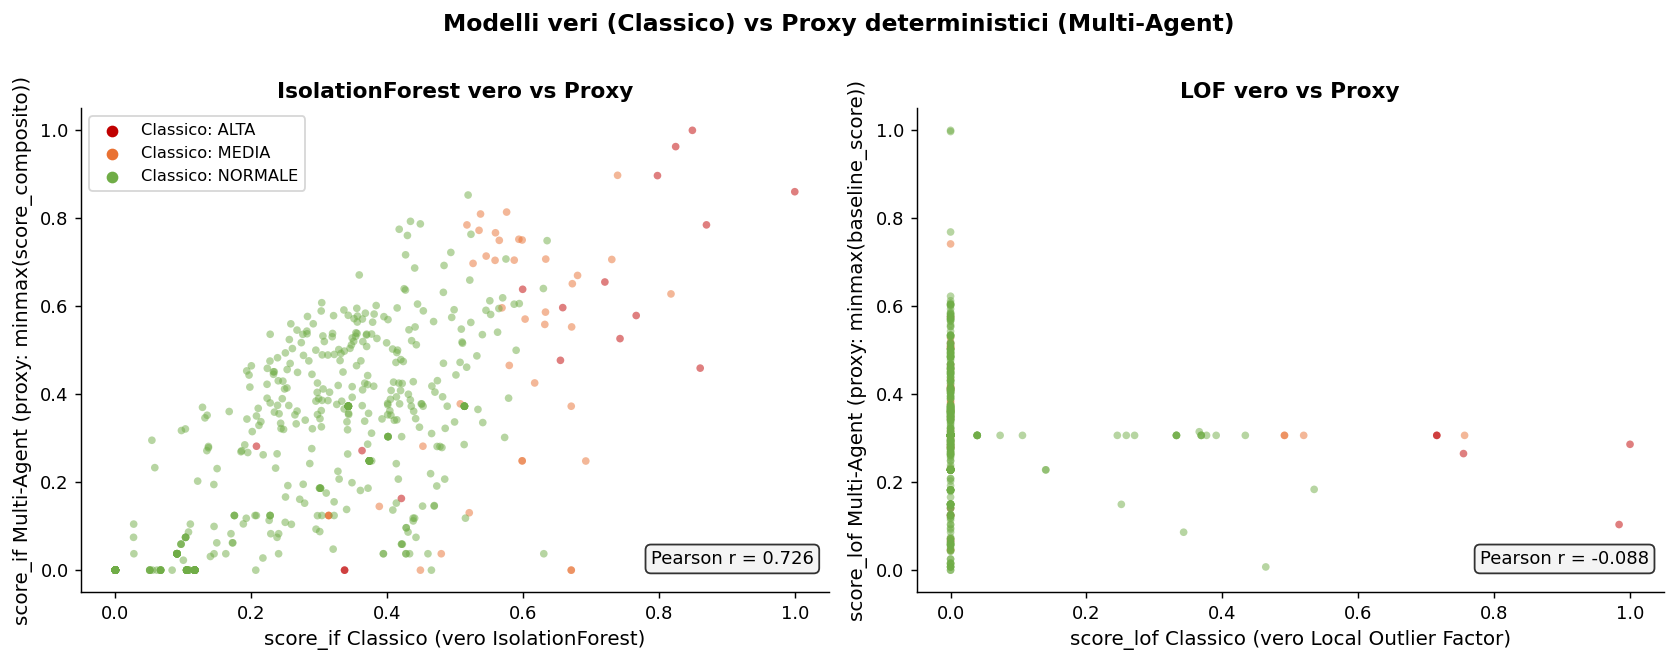


Correlazione IF  (vero vs proxy): r = 0.7261
Correlazione LOF (vero vs proxy): r = -0.0881

→ Bassa correlazione: i proxy non approssimano bene i modelli ML veri.
→ Il passo successivo è integrare i modelli scikit-learn veri nell'OutlierAgent.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Confronto score_if vero vs proxy --
ax = axes[0]
ax.scatter(cl["anomaly_score_if"], ma["score_if"],
           c=cl["anomaly_label"].map(COLORS), alpha=0.5, s=18, edgecolors="none")
r_if, _ = pearsonr(cl["anomaly_score_if"], ma["score_if"])
ax.set_xlabel("score_if Classico (vero IsolationForest)", fontsize=11)
ax.set_ylabel("score_if Multi-Agent (proxy: minmax(score_composito))", fontsize=11)
ax.set_title("IsolationForest vero vs Proxy", fontsize=12, fontweight="bold")
ax.text(0.98, 0.05, f"Pearson r = {r_if:.3f}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=10,
        bbox=dict(boxstyle="round", facecolor="#F2F2F2", alpha=0.8))

# -- Confronto score_lof vero vs proxy --
ax2 = axes[1]
ax2.scatter(cl["anomaly_score_lof"], ma["score_lof"],
            c=cl["anomaly_label"].map(COLORS), alpha=0.5, s=18, edgecolors="none")
r_lof, _ = pearsonr(cl["anomaly_score_lof"], ma["score_lof"])
ax2.set_xlabel("score_lof Classico (vero Local Outlier Factor)", fontsize=11)
ax2.set_ylabel("score_lof Multi-Agent (proxy: minmax(baseline_score))", fontsize=11)
ax2.set_title("LOF vero vs Proxy", fontsize=12, fontweight="bold")
ax2.text(0.98, 0.05, f"Pearson r = {r_lof:.3f}",
         transform=ax2.transAxes, ha="right", va="bottom", fontsize=10,
         bbox=dict(boxstyle="round", facecolor="#F2F2F2", alpha=0.8))

# Legenda colori
for lab, col in [("ALTA","#C00000"),("MEDIA","#E97132"),("NORMALE","#70AD47")]:
    axes[0].scatter([], [], color=col, label=f"Classico: {lab}", s=30)
axes[0].legend(fontsize=9)

plt.suptitle("Modelli veri (Classico) vs Proxy deterministici (Multi-Agent)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nCorrelazione IF  (vero vs proxy): r = {r_if:.4f}")
print(f"Correlazione LOF (vero vs proxy): r = {r_lof:.4f}")
print("\n→ Bassa correlazione: i proxy non approssimano bene i modelli ML veri.")
print("→ Il passo successivo è integrare i modelli scikit-learn veri nell'OutlierAgent.")

## 8 · Delta rank — quanto cambiano le posizioni?

=== STATISTICHE DELTA RANK ===
Delta medio:   131.6 posizioni
Delta mediano: 103.0 posizioni
Delta max:     526 posizioni (rotta: GYD-FCO)
Delta < 50:    158 rotte (27.9%)
Delta < 100:   257 rotte (45.3%)


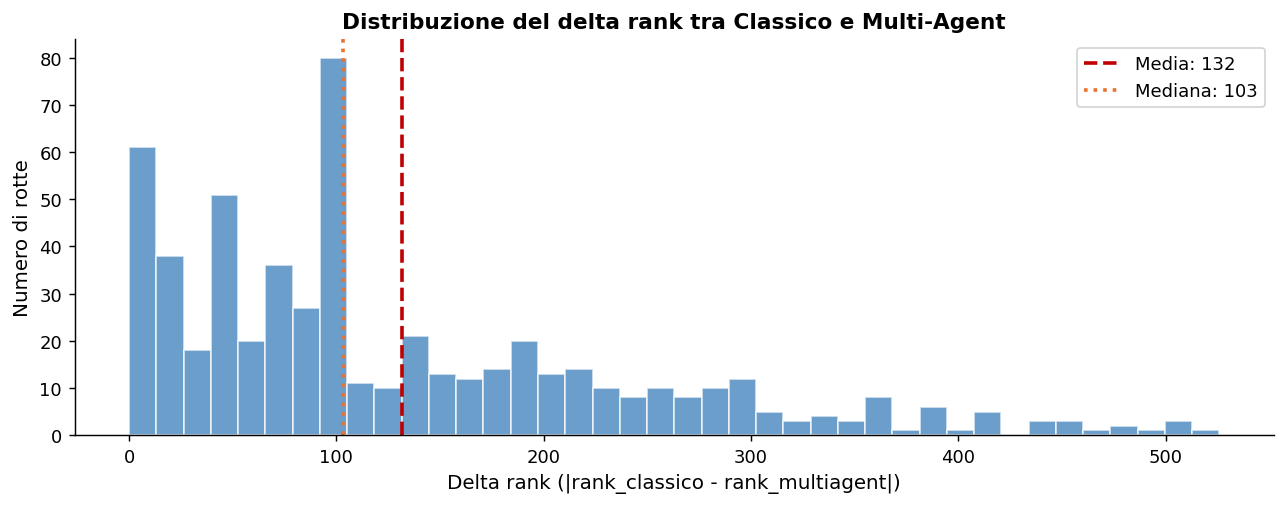

In [9]:
cl_rank = cl["anomaly_score"].rank(ascending=False).astype(int)
ma_rank = ma["ensemble_score"].rank(ascending=False).astype(int)
delta_rank = (cl_rank - ma_rank).abs()

print("=== STATISTICHE DELTA RANK ===")
print(f"Delta medio:   {delta_rank.mean():.1f} posizioni")
print(f"Delta mediano: {delta_rank.median():.1f} posizioni")
print(f"Delta max:     {delta_rank.max():.0f} posizioni (rotta: {delta_rank.idxmax()})")
print(f"Delta < 50:    {(delta_rank < 50).sum()} rotte ({(delta_rank < 50).sum()/len(common)*100:.1f}%)")
print(f"Delta < 100:   {(delta_rank < 100).sum()} rotte ({(delta_rank < 100).sum()/len(common)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(delta_rank, bins=40, color=COLORS["classico"], alpha=0.7, edgecolor="white")
ax.axvline(delta_rank.mean(),   color="#C00000", lw=2, linestyle="--", label=f"Media: {delta_rank.mean():.0f}")
ax.axvline(delta_rank.median(), color="#E97132", lw=2, linestyle=":",  label=f"Mediana: {delta_rank.median():.0f}")
ax.set_xlabel("Delta rank (|rank_classico - rank_multiagent|)", fontsize=11)
ax.set_ylabel("Numero di rotte", fontsize=11)
ax.set_title("Distribuzione del delta rank tra Classico e Multi-Agent", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 9 · Riepilogo e conclusioni

In [10]:
r_pearson, _ = pearsonr(cl["anomaly_score"], ma["ensemble_score"])
rho, pval    = spearmanr(cl["anomaly_score"], ma["ensemble_score"])
agree        = int((cl["anomaly_label"] == ma["risk_label"]).sum())

print("="*60)
print("     RIEPILOGO CONFRONTO CLASSICO vs MULTI-AGENT")
print("="*60)
print(f"\n📊 DISTRIBUZIONE")
print(f"   Classico:    17 ALTA  | 40 MEDIA  | 510 NORMALE")
print(f"   Multi-Agent: {dist_ma.get('ALTA',0)} ALTA | {dist_ma.get('MEDIA',0)} MEDIA | {dist_ma.get('NORMALE',0)} NORMALE")
print(f"\n🤝 ACCORDO")
print(f"   Stessa label:       {agree}/{len(common)} rotte ({agree/len(common)*100:.1f}%)")
print(f"   ALTA in entrambi:   {len(both_alta)} rotte  ← anomalie robuste")
print(f"   Solo Classico ALTA: {len(only_cl)} rotte")
print(f"   Solo MA ALTA:       {len(only_ma)} rotte")
print(f"\n📈 CORRELAZIONE SCORE")
print(f"   Pearson r  = {r_pearson:.4f}  (correlazione lineare moderata)")
print(f"   Spearman ρ = {rho:.4f}  (correlazione di rank moderata)")
print(f"\n⚠️  CAUSA PRINCIPALE DELLE DIFFERENZE")
print(f"   Il Multi-Agent usa proxy deterministici per IF e LOF:")
print(f"   score_if = minmax(score_composito)  → proxy volume-based")
print(f"   score_lof = minmax(baseline_score)  → proxy z-score-based")
print(f"   I modelli veri (scikit-learn) rilevano outlier statistici")
print(f"   indipendentemente dal volume → risultati diversi.")
print(f"\n✅ PASSO SUCCESSIVO")
print(f"   Integrare IsolationForest e LOF veri nell'OutlierAgent.")
print(f"   Il codice è già strutturato per farlo senza modifiche")
print(f"   agli altri agenti (solo OutlierAgent da aggiornare).")
print("="*60)

     RIEPILOGO CONFRONTO CLASSICO vs MULTI-AGENT

📊 DISTRIBUZIONE
   Classico:    17 ALTA  | 40 MEDIA  | 510 NORMALE
   Multi-Agent: 196 ALTA | 66 MEDIA | 305 NORMALE

🤝 ACCORDO
   Stessa label:       292/567 rotte (51.5%)
   ALTA in entrambi:   9 rotte  ← anomalie robuste
   Solo Classico ALTA: 8 rotte
   Solo MA ALTA:       187 rotte

📈 CORRELAZIONE SCORE
   Pearson r  = 0.4166  (correlazione lineare moderata)
   Spearman ρ = 0.4353  (correlazione di rank moderata)

⚠️  CAUSA PRINCIPALE DELLE DIFFERENZE
   Il Multi-Agent usa proxy deterministici per IF e LOF:
   score_if = minmax(score_composito)  → proxy volume-based
   score_lof = minmax(baseline_score)  → proxy z-score-based
   I modelli veri (scikit-learn) rilevano outlier statistici
   indipendentemente dal volume → risultati diversi.

✅ PASSO SUCCESSIVO
   Integrare IsolationForest e LOF veri nell'OutlierAgent.
   Il codice è già strutturato per farlo senza modifiche
   agli altri agenti (solo OutlierAgent da aggiornare).
